In [1]:
from pathlib import Path
import re
import os
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
import matplotlib.pyplot as plt
import pandas as pd
from adjustText import adjust_text
import numpy as np
from IPython.display import display, Markdown


In [7]:
def limpiar_markdown(texto):
    texto = re.sub(r"```.*?```", " ", texto, flags=re.S)
    texto = re.sub(r"\$\$.*?\$\$", " ", texto, flags=re.S)
    texto = re.sub(r"`[^`]*`", " ", texto)
    texto = re.sub(r"\[[^\]]*\]\([^\)]*\)", " ", texto)
    texto = re.sub(r"[^\w ]", " ", texto, flags=re.UNICODE)
    texto = re.sub(r"\s+", " ", texto)
    return texto.lower().strip()
paths = [Path("docs/documento_01.txt"), Path("docs/documento_02.txt")]
paths = [Path(f"docs/documento_0{i+1}.txt") for i in range(4)]


documentos = [limpiar_markdown(path.read_text(encoding="utf-8")) for path in paths]
etiquetas = [f"docs/documento_0{i+1}.txt" for i in range(4)]

print(f"Documentos de semanas 01-07: {len(documentos)}")
for etiqueta in etiquetas:
    print(f" - {etiqueta}")

Documentos de semanas 01-07: 4
 - docs/documento_01.txt
 - docs/documento_02.txt
 - docs/documento_03.txt
 - docs/documento_04.txt


In [8]:
for style in ["seaborn-v0_8-whitegrid", "seaborn-whitegrid", "default"]:
    if style in plt.style.available or style == "default":
        plt.style.use(style)
        break

vectorizer_raw = CountVectorizer(
    lowercase=True,
    token_pattern=r"(?u)\b[^\W\d_]{3,}\b",
    min_df=1,
)

X_raw = vectorizer_raw.fit_transform(documentos)
vocabulario_raw = vectorizer_raw.get_feature_names_out()
A_raw = X_raw.toarray().T

print("Forma de X_raw (documentos x terminos):", X_raw.shape)
print("Forma de A_raw (terminos x documentos):", A_raw.shape)
print("Primeros terminos del vocabulario:", vocabulario_raw[:300])

Forma de X_raw (documentos x terminos): (4, 1210)
Forma de A_raw (terminos x documentos): (1210, 4)
Primeros terminos del vocabulario: ['abadejo' 'abundanciaxvi' 'abusosi' 'acabar' 'acabó' 'acaso' 'acertaron'
 'acertó' 'acomodada' 'acomodar' 'acomodándole' 'acomodársele' 'acompañar'
 'acontece' 'acontecerle' 'acordándose' 'acrecentaba' 'acuitedes' 'adarga'
 'adelante' 'además' 'aderezólas' 'adherentes' 'administración' 'adonde'
 'afable' 'afición' 'afincamiento' 'agradables' 'agravio' 'agravios'
 'aguardar' 'ahogó' 'ahora' 'ahí' 'alababa' 'alabado' 'alborozo' 'alcaide'
 'alcázares' 'aldea' 'aldonza' 'alejandro' 'algo' 'alguna' 'algunas'
 'alguno' 'algunos' 'algún' 'allende' 'allí' 'almenas' 'altas' 'alto'
 'altos' 'alzada' 'alzándose' 'ama' 'amadís' 'amigo' 'amor' 'amores'
 'amén' 'anales' 'ancha' 'andaba' 'andaban' 'andalucía' 'andante'
 'andantes' 'anduvo' 'anochecer' 'anochecía' 'ansí' 'ante' 'anteovii'
 'antes' 'antigua' 'antiguo' 'apariencia' 'apear' 'apenas' 'apeó' 'apolo'
 'apre

,estadistica,corpus_sin_limpieza
0,numero_documentos,4
1,numero_terminos,1210
2,forma_X_documentos_x_terminos,4 x 1210
3,forma_A_terminos_x_documentos,1210 x 4
4,entradas_no_cero,1635
5,densidad,0.3378
6,sparsity,0.6622


,estadistica,corpus_sin_limpieza
0,min,596.00
1,mediana,662.00
2,media,677.25
3,max,789.00


,estadistica,corpus_sin_limpieza
0,min,372.00
1,mediana,392.00
2,media,408.75
3,max,478.00


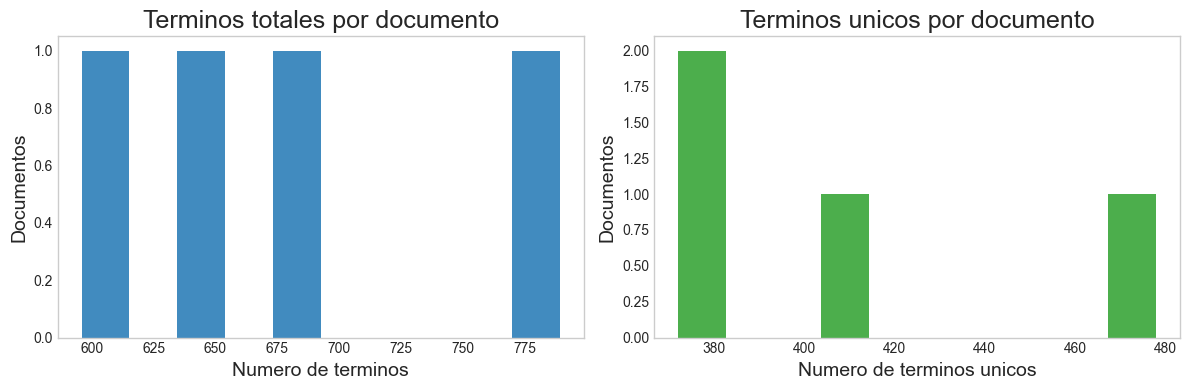

In [9]:
def tabla_resumen_distribucion(nombre, valores):
    return pd.DataFrame(
        [
            ["min", int(valores.min())],
            ["mediana", int(np.median(valores))],
            ["media", round(float(valores.mean()), 2)],
            ["max", int(valores.max())],
        ],
        columns=["estadistica", nombre],
    )


def resumen_vectorizacion(nombre, X, A, vocabulario):
    conteos_por_doc = np.asarray(X.sum(axis=1)).ravel()
    terminos_unicos_por_doc = np.asarray((X > 0).sum(axis=1)).ravel()
    total_celdas = X.shape[0] * X.shape[1]
    densidad = X.nnz / total_celdas

    tabla_corpus = pd.DataFrame(
        [
            ["numero_documentos", X.shape[0]],
            ["numero_terminos", X.shape[1]],
            ["forma_X_documentos_x_terminos", f"{X.shape[0]} x {X.shape[1]}"],
            ["forma_A_terminos_x_documentos", f"{A.shape[0]} x {A.shape[1]}"],
            ["entradas_no_cero", X.nnz],
            ["densidad", round(float(densidad), 4)],
            ["sparsity", round(float(1 - densidad), 4)],
        ],
        columns=["estadistica", nombre],
    )
    tabla_terminos_por_doc = tabla_resumen_distribucion(nombre, conteos_por_doc)
    tabla_terminos_unicos_por_doc = tabla_resumen_distribucion(nombre, terminos_unicos_por_doc)

    return (
        tabla_corpus,
        tabla_terminos_por_doc,
        tabla_terminos_unicos_por_doc,
        conteos_por_doc,
        terminos_unicos_por_doc,
    )

(
    tabla_corpus_raw,
    tabla_terminos_por_doc_raw,
    tabla_terminos_unicos_por_doc_raw,
    conteos_doc_raw,
    terminos_unicos_doc_raw,
) = resumen_vectorizacion(
    "corpus_sin_limpieza",
    X_raw,
    A_raw,
    vocabulario_raw,
)

display(tabla_corpus_raw)
display(tabla_terminos_por_doc_raw)
display(tabla_terminos_unicos_por_doc_raw)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(conteos_doc_raw, bins=10, color="tab:blue", alpha=0.85)
axes[0].set_title("Terminos totales por documento", fontsize=18)
axes[0].set_xlabel("Numero de terminos", fontsize=14)
axes[0].set_ylabel("Documentos", fontsize=14)
axes[0].grid(False)

axes[1].hist(terminos_unicos_doc_raw, bins=10, color="tab:green", alpha=0.85)
axes[1].set_title("Terminos unicos por documento", fontsize=18)
axes[1].set_xlabel("Numero de terminos unicos", fontsize=14)
axes[1].set_ylabel("Documentos", fontsize=14)
axes[1].grid(False)

plt.tight_layout()
plt.show()

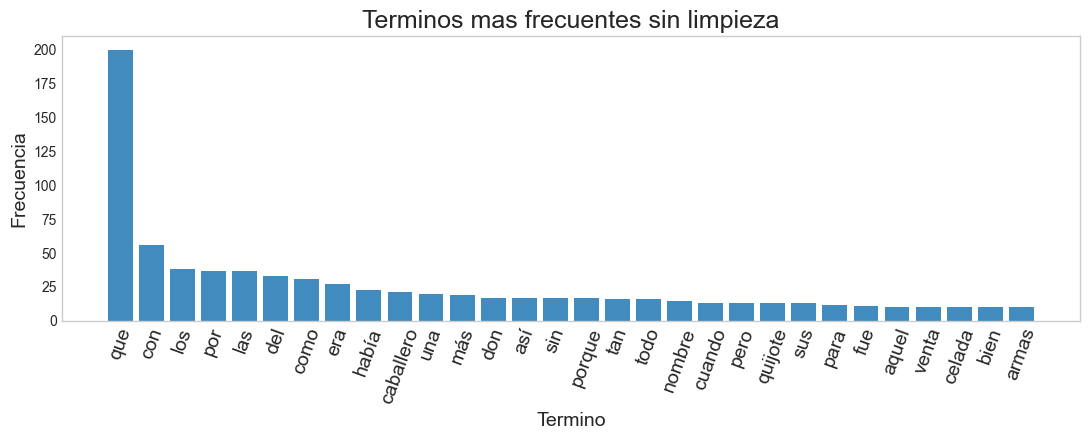

Top 30 terminos mas frecuentes sin limpieza:


array(['que', 'con', 'los', 'por', 'las', 'del', 'como', 'era', 'había',
       'caballero', 'una', 'más', 'don', 'así', 'sin', 'porque', 'tan',
       'todo', 'nombre', 'cuando', 'pero', 'quijote', 'sus', 'para',
       'fue', 'aquel', 'venta', 'celada', 'bien', 'armas'], dtype=object)

In [10]:
frecuencias_raw = np.asarray(X_raw.sum(axis=0)).ravel()
indices_frecuentes_raw = np.argsort(frecuencias_raw)[::-1][:30]
terminos_frecuentes_raw = vocabulario_raw[indices_frecuentes_raw]
conteos_frecuentes_raw = frecuencias_raw[indices_frecuentes_raw]

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.bar(terminos_frecuentes_raw, conteos_frecuentes_raw, color="tab:blue", alpha=0.85)
ax.set_title("Terminos mas frecuentes sin limpieza", fontsize=18)
ax.set_xlabel("Termino", fontsize=14)
ax.set_ylabel("Frecuencia", fontsize=14)
ax.grid(False)
ax.tick_params(axis="x", rotation=70, labelsize=14)
plt.tight_layout()
plt.show()

# Print top 30 terms and their counts
print("Top 30 terminos mas frecuentes sin limpieza:")
terminos_frecuentes_raw